# Download bibliotecas

In [1]:
!pip install numpy==1.23.5 pandas==2.2.2

In [2]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 23.0 MB/s eta 0:00:00


# Importando dados

In [3]:
import pandas as pd
import os
import numpy as np
from google.colab import drive

drive.mount('/content/drive')

caminho_dados = '/content/drive/Shareddrives/IC - Otimizacao computacional para inflacao/Dados'

# Listar os arquivos dentro da pasta "Dados"
arquivos_dados = os.listdir(caminho_dados)

print(arquivos_dados)


Mounted at /content/drive
['dados_macro.ipynb', 'df_macro.csv']


In [4]:
file_path = os.path.join(caminho_dados, 'df_macro.csv')

df = pd.read_csv(file_path, index_col='Date', parse_dates=True)


# Funcoes auxiliares

In [5]:
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import joblib

# Funções auxiliares

def make_stationary(df, max_diff=5):
    """Torna a série temporal estacionária através de diferenciação."""
    df_diff = df.copy()
    for i in range(1, max_diff + 1):
        stationary = True
        for column in df_diff.columns:
            if not check_stationarity(df_diff[[column]]):
                stationary = False
                df_diff[[column]] = df_diff[[column]].diff().fillna(method='ffill').fillna(method='bfill')
        if stationary:
            print(f"Série estacionária após {i-1} diferenciações.")
            return df_diff.dropna()
    raise ValueError("A série não se tornou estacionária após o número máximo de diferenciações.")

def check_stationarity(series, significance_level=0.05):
    """Verifica se a série é estacionária usando o teste ADF."""
    from statsmodels.tsa.stattools import adfuller
    result = adfuller(series.dropna())
    return result[1] < significance_level

def plot_forecasts(y_test, final_forecast, title='Previsão Dinâmica'):
    """Plota as previsões comparadas com os valores reais."""
    plt.figure(figsize=(15, 3))
    plt.plot(y_test.index, y_test, label='Valores Reais', color='blue')
    plt.plot(y_test.index, final_forecast, label='Previsão', color='orange')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


# Implementacao Arima

In [6]:
import warnings

# Ignorar todos os warnings
warnings.filterwarnings("ignore")


Série estacionária após 2 diferenciações.
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=126.122, Time=0.63 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=262.064, Time=0.07 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=135.136, Time=0.11 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=193.641, Time=0.85 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=125.469, Time=1.10 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=175.043, Time=0.17 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=127.149, Time=0.18 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=127.251, Time=1.44 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=157.652, Time=2.16 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=124.310, Time=3.14 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=130.885, Time=0.09 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=129.513, Time=0.55 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=127.620, Time=0.27 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=127.423, Time=3.99 sec
 ARIM

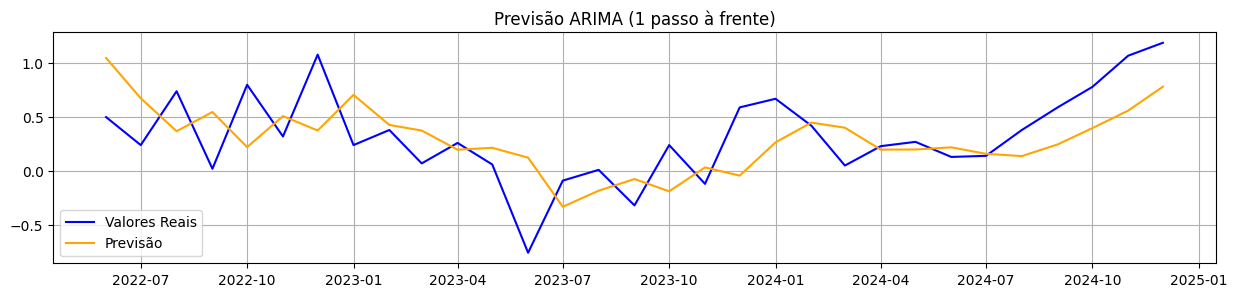

In [7]:

# Função principal
if __name__ == "__main__":
    # Tornar o DataFrame estacionário
    df_stationary = make_stationary(df)

    # Dividir em conjunto de treino e teste
    train_size = int(len(df_stationary) * 0.8)
    train, test = df_stationary.iloc[:train_size], df_stationary.iloc[train_size:]

    # Variável dependente
    y_train = train['IPCA']
    y_test = test['IPCA']

    # Ajuste do modelo ARIMA usando pmdarima (sem sazonalidade)
    arima_model = auto_arima(y_train, seasonal=False, trace=True, error_action='ignore', suppress_warnings=True)
    arima_order = arima_model.order

    # Previsão dinâmica com ARIMA no conjunto de teste para 1 passo à frente
    history = list(y_train)
    dynamic_arima_forecast = []

    for t in range(len(y_test)):
        # Ajuste do modelo SARIMAX dinamicamente para 1 passo
        arima_dynamic = SARIMAX(history, order=arima_order).fit(disp=False)
        arima_pred = arima_dynamic.forecast(steps=1)
        dynamic_arima_forecast.append(arima_pred[0])

        # Atualizar o histórico de variáveis dependentes
        history.append(y_test.iloc[t])

    # Calcular e salvar as previsões finais
    final_forecast_df = pd.DataFrame(dynamic_arima_forecast, index=y_test.index[:len(dynamic_arima_forecast)], columns=['Final_Forecast'])
    final_forecast_df.to_csv('arima_pred.csv', index=True)

    # Salvar o modelo ARIMA
    joblib.dump(arima_model, 'arima_model.pkl')  # Salva o modelo

    # Calcular os resíduos
    residuals = y_test[:len(dynamic_arima_forecast)] - dynamic_arima_forecast
    residuals_df = pd.DataFrame(residuals, index=y_test.index[:len(dynamic_arima_forecast)], columns=['Residuals'])
    residuals_df.to_csv('arima_res.csv', index=True)  # Salva os resíduos

    # Métricas de erro
    mse = mean_squared_error(y_test[:len(dynamic_arima_forecast)], dynamic_arima_forecast)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test[:len(dynamic_arima_forecast)], dynamic_arima_forecast)
    mape = np.mean(np.abs((y_test[:len(dynamic_arima_forecast)] - dynamic_arima_forecast) / y_test[:len(dynamic_arima_forecast)]))
    r2 = r2_score(y_test[:len(dynamic_arima_forecast)], dynamic_arima_forecast)

    print(f'MAE: {mae:.6f}')
    print(f'MSE: {mse:.6f}')
    print(f'RMSE: {rmse:.6f}')
    print(f'MAPE: {mape:.6f}')

    # Plotar as previsões
    plot_forecasts(y_test[:len(dynamic_arima_forecast)], dynamic_arima_forecast, title='Previsão ARIMA (1 passo à frente)')

# Implementacao Arima + RF


In [8]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Obter os resíduos do ARIMA
residuals = y_test[:len(dynamic_arima_forecast)] - dynamic_arima_forecast
residuals = residuals.reset_index(drop=True)

# Features para o Random Forest (todas exceto a variável alvo 'IPCA')
X_rf = test.drop(columns=['IPCA']).iloc[:len(residuals)].reset_index(drop=True)

# Alvo: resíduos do ARIMA
y_rf = residuals

# Dividir dados para treino e teste do Random Forest
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(X_rf, y_rf, test_size=0.2, random_state=42)

# Treinar modelo Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_rf, y_train_rf)


RandomForestRegressor(random_state=42)

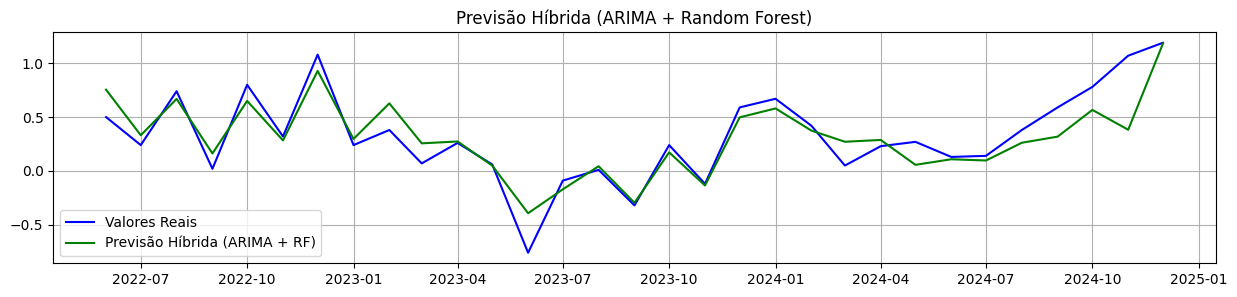


--- Métricas do Modelo Híbrido (ARIMA + Random Forest) ---
MAE: 0.131731
MSE: 0.036029
RMSE: 0.189813
MAPE: 0.824491


In [9]:
# Prever os resíduos com o modelo Random Forest
rf_predicted_residuals = rf_model.predict(X_rf)

# Somar a previsão do ARIMA com a previsão dos resíduos
hybrid_forecast = np.array(dynamic_arima_forecast) + rf_predicted_residuals

# Plotando o modelo híbrido
plt.figure(figsize=(15, 3))
plt.plot(y_test.index[:len(hybrid_forecast)], y_test[:len(hybrid_forecast)], label='Valores Reais', color='blue')
plt.plot(y_test.index[:len(hybrid_forecast)], hybrid_forecast, label='Previsão Híbrida (ARIMA + RF)', color='green')
plt.title('Previsão Híbrida (ARIMA + Random Forest)')
plt.legend()
plt.grid(True)
plt.show()

# Cálculo das métricas
mae_hybrid = mean_absolute_error(y_test[:len(hybrid_forecast)], hybrid_forecast)
mse_hybrid = mean_squared_error(y_test[:len(hybrid_forecast)], hybrid_forecast)
rmse_hybrid = np.sqrt(mse_hybrid)
mape_hybrid = np.mean(np.abs((y_test[:len(hybrid_forecast)] - hybrid_forecast) / y_test[:len(hybrid_forecast)]))

# Impressão dos resultados
print("\n--- Métricas do Modelo Híbrido (ARIMA + Random Forest) ---")
print(f'MAE: {mae_hybrid:.6f}')
print(f'MSE: {mse_hybrid:.6f}')
print(f'RMSE: {rmse_hybrid:.6f}')
print(f'MAPE: {mape_hybrid:.6f}')
